# Cross-slope section

### Background

This recipe computes a cross-section across the Antarctic continental slope, as defined by the 1000 m isobath. We will do the cross-section using an example field through the gridded data of ACCESS-OM2-01 using the  `metpy.interpolate.cross_section` function. For more information on how `metpy` works refer to their [documentation](https://unidata.github.io/MetPy/latest/examples/cross_section.html#sphx-glr-examples-cross-section-py). It is a very useful library!

---

### Requirements

This recipe works with MOM5 diagnostics from ACCESS-OM2-01. For adaptation to MOM6 the following diagnostics will be useful:

| MOM5 diagnostic (x-coord, y-coord) | MOM6 diagnostic (x-coord,y-coord)|
|---|---|
|`pot_rho_2 (xt_ocean,yt_ocean)` | `rhopot2(xh,yh)`|
|`pot_temp (xt_ocean,yt_ocean)` | `thetao(xh,yh)`|
|`ht (xt_ocean,yt_ocean)` | `deptho(xh,yh)`|
|`hu (xu_ocean,yu_ocean)` | N/A |
|`dxt (xt_ocean,yt_ocean)` | `dxt(xh,yh)`|

When calculating the normal directions, take into account that the MOM6 diagnostics might not be in the same grid as this recipe.

In [1]:
import cartopy.crs as ccrs
import cmocean as cm
import intake
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xgcm
from dask.distributed import Client
from metpy.interpolate import cross_section

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [2]:
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40417,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33379,Total threads: 1
Dashboard: /proxy/39741/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:35405,


Open the intake catalog and select experiment:

In [3]:
catalog = intake.cat.access_nri
experiment = '01deg_jra55v13_ryf9091'

### Load data

We will do a cross section of potential temperature with potential density contours, we will open only 5 years of data (from 1950-1955). Let's also load bathymetry and grid distances data, which we will need to get the cross-slope direction

In [ ]:
bathymetry = catalog[experiment].search(variable=["ht","hu"],
                                        frequency="fx").to_dask()
grid_distances = catalog[experiment].search(variable=["dxt", "dyt"],
                                            frequency="fx").to_dask()

ds = catalog[experiment].search(variable=["pot_rho_2","pot_temp"],
                                start_date='^195[0-5].*',
                                frequency="1mon",
                                variable_cell_methods="time: mean"
                                ).to_dask()
ds = ds.mean('time')

In order to do a cross-slope section, we need to find the direction that is normal to the slope (a detailed description can be found in the [Along-slope-velocities](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Along-slope-velocities.ipynb) notebook - in this recipe we take the direction normal to bathymetry, instead of the one along.

We will use `xgcm` in order to calculate the necessary gradients. Remember that the direction normal $\hat{\eta}$ to topography, $h$, is given by:

$$
\hat{\eta} = \partial_x h \; \hat{x} \; , \;\; \partial_y h \; \hat{y}
$$

In [8]:
bathymetry.coords['xt_ocean'].attrs.update(axis='X')
bathymetry.coords['xu_ocean'].attrs.update(axis='X', c_grid_axis_shift=0.5)
bathymetry.coords['yt_ocean'].attrs.update(axis='Y')
bathymetry.coords['yu_ocean'].attrs.update(axis='Y', c_grid_axis_shift=0.5)

# Create grid object
grid = xgcm.Grid(bathymetry, periodic=['X'])

# Calculate the gradients
dxht = grid.interp(grid.diff(bathymetry["hu"], 'X'), "Y") / grid_distances['dxt']
dyht = grid.interp(grid.diff(bathymetry["hu"], 'Y'), "X") / grid_distances['dyt']

# Normalise to get the direction
n_x = dxht / np.sqrt(dxht**2 + dyht**2)
n_y = dyht / np.sqrt(dxht**2 + dyht**2)

Let's open the Antarctic slope file, which marks the grid-cells belonging to the slope (1000 m isobath):

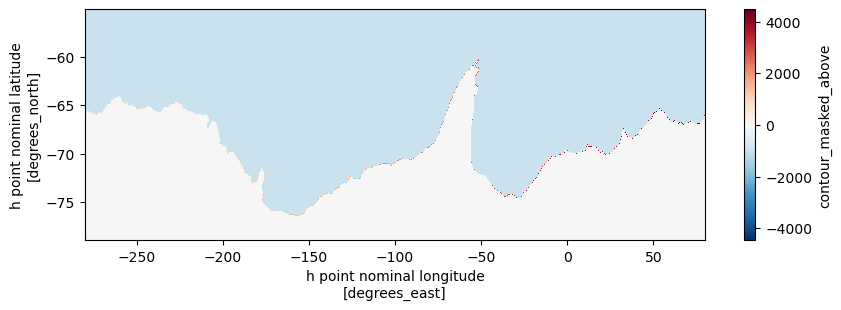

In [9]:
ant_slope = xr.open_dataset('/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc')['contour_masked_above']
ant_slope = ant_slope.rename({'xh':'xt_ocean','yh':'yt_ocean'})

ant_slope.plot(figsize=(10,3));

As you can see, everything in the open ocean is <0, and points along the slope are indexed from zero to 4475. 

Let's select a something on the Antarctic peninsula.

In [10]:
np.where(ant_slope==2422)

(array([287]), array([2074]))

In [11]:
slope_lat_idx = np.where(ant_slope==2422)[0][0]
slope_lon_idx = np.where(ant_slope==2422)[1][0]

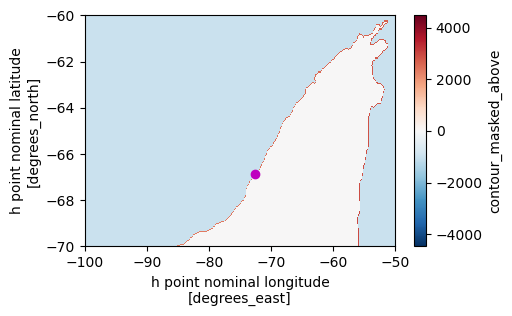

In [12]:
ant_slope.plot(figsize=(5,3))
plt.scatter(ant_slope['xt_ocean'][slope_lon_idx], ant_slope['yt_ocean'][slope_lat_idx], color='m');
plt.xlim(-100,-50)
plt.ylim(-70,-60);

Let's look at what the direction normal to that point is:

In [13]:
n_x.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


array(-0.94928837, dtype=float32)

In [14]:
n_y.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values

array(0.31440672, dtype=float32)

Now we can use these directions to select our starting and ending latitude, longitude coordinates to feed `metpy` for the cross-section. 

In [44]:
# Points at the slope
slope_lon = ant_slope['xt_ocean'][slope_lon_idx].item()
slope_lat = ant_slope['yt_ocean'][slope_lat_idx].item()

# Points on the shelf
shelf_lon = slope_lon - 3*n_x.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values
shelf_lat = slope_lat - 3*n_y.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values

# Points off the shelf
offshelf_lon = slope_lon + 5*n_x.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values
offshelf_lat = slope_lat + 5*n_y.isel(yt_ocean=slope_lat_idx, xt_ocean=slope_lon_idx).values

Let's check what it looks like:

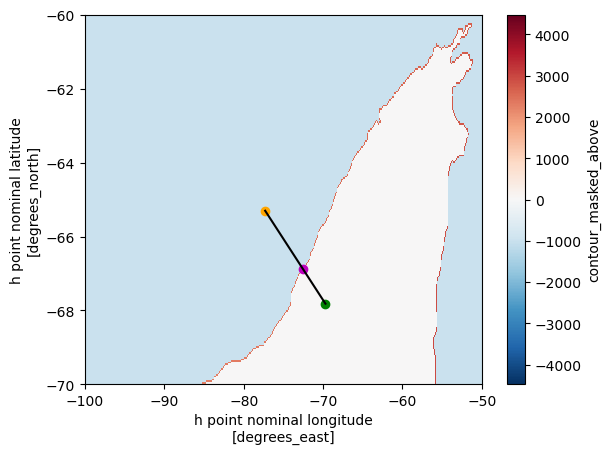

In [45]:
ant_slope.plot()
plt.plot([shelf_lon, offshelf_lon], [shelf_lat,offshelf_lat], color='k')
plt.scatter(slope_lon, slope_lat, color='m');
plt.scatter(shelf_lon, shelf_lat, color='g')
plt.scatter(offshelf_lon, offshelf_lat, color='orange')
plt.xlim(-100,-50)
plt.ylim(-70,-60);

The black line marks the cross-section that is normal to the slope at the magenta dot. Green and orange dots are the coordinates we will pass on to `metpy`.

In [46]:
# Create datasets
ds = ds.sel(xt_ocean=slice(-100,-50), yt_ocean=slice(-70,-60))
ds_pot_rho_2 = xr.Dataset({"pot_rho_2": ds["pot_rho_2"], "lat": ds.yt_ocean, "lon": ds.xt_ocean})
ds_pot_temp = xr.Dataset({"pot_temp": ds["pot_temp"], "lat": ds.yt_ocean, "lon": ds.xt_ocean})

# Rename coordinates for metpy
ds_pot_rho_2 = ds_pot_rho_2.rename({'xt_ocean': 'x', 'yt_ocean': 'y'})
ds_pot_temp = ds_pot_temp.rename({'xt_ocean': 'x', 'yt_ocean': 'y'})

# Parse
potrho2_parsed = ds_pot_rho_2.metpy.parse_cf('pot_rho_2', coordinates={'y': 'y', 'x': 'x'})
pottemp_parsed = ds_pot_temp.metpy.parse_cf('pot_temp', coordinates={'y': 'y', 'x': 'x'})

# Do the cross section
pot_rho_2_section = cross_section(potrho2_parsed,
                                  start=(shelf_lat, shelf_lon),
                                  end=(offshelf_lat, offshelf_lon),
                                  steps = 400,
                                  interp_type='linear')

pottemp_section = cross_section(pottemp_parsed, 
                                start=(shelf_lat, shelf_lon),
                                end=(offshelf_lat, offshelf_lon),
                                steps = 400,
                                interp_type='linear')

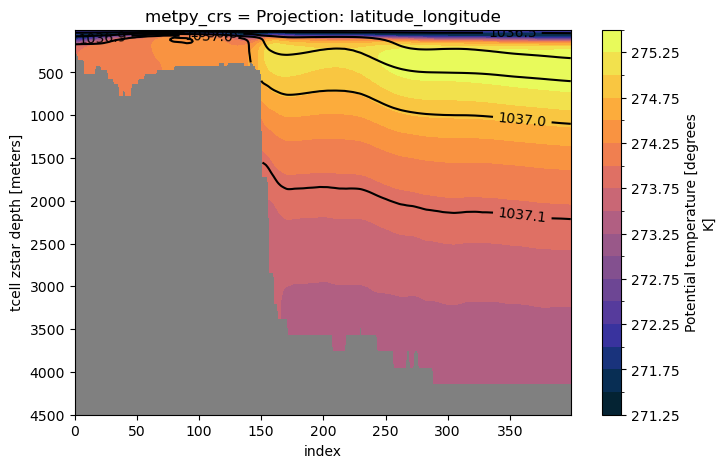

In [47]:
pottemp_section.plot.contourf(figsize=(8,5),
                              yincrease=False,
                              levels=21,
                              cmap=cm.cm.thermal)
cs=pot_rho_2_section.plot.contour(yincrease=False,
                                  levels=[1036.5,1036.8, 1036.9, 1037, 1037.1],
                                  colors=['k'])
plt.clabel(cs, cs.levels,
           colors = 'k',
           inline = True,
           use_clabeltext = True)
plt.gca().set_facecolor('grey')
plt.ylim(4500,None);

Note that our x-axis is an "index" - we can replace this with a "distance from isobath" coordinate.

In [ ]:
# Radius of the Earth
Rearth = 6371 # km
distance = np.empty(400)
for i in range(400):
    # Difference between points in lat/lon space
    dlon = pottemp_section["x"][i] - slope_lon
    dlat = pottemp_section["y"][i] - slope_lat
    
    distance[i] = Rearth * np.deg2rad(np.sqrt(dlat**2 + (dlon * np.cos(np.deg2rad(np.mean([slope_lat]))))**2))

distance = xr.DataArray(distance, dims=['index'], coords={'index':pottemp_section['index']})

In [51]:
# Make everything on shelf negative
np.where(distance==np.min(distance))

(array([147]),)

In [52]:
distance = xr.where(distance['index']<147, -distance, distance)

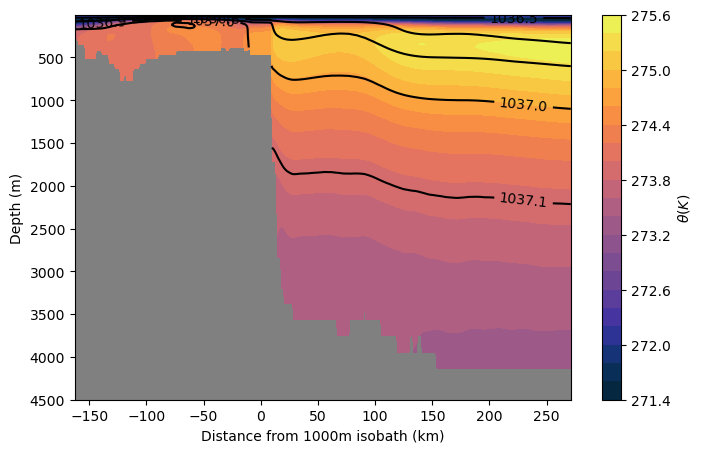

In [56]:
plt.figure(figsize=(8,5))

plt.contourf(distance, 
             pottemp_section['st_ocean'], 
             pottemp_section,
             levels=21,
             cmap=cm.cm.thermal)
plt.colorbar().set_label('$\\theta (K)$');

cs=plt.contour(distance, 
               pot_rho_2_section['st_ocean'], 
               pot_rho_2_section,
               levels=[1036.5,1036.8, 1036.9, 1037, 1037.1],
               colors=['k'])
plt.clabel(cs, cs.levels,
           colors = 'k',
           inline = True,
           use_clabeltext = True)
plt.gca().set_facecolor('grey')
plt.gca().invert_yaxis();
plt.ylim(4500,None);
plt.xlabel('Distance from 1000m isobath (km)')
plt.ylabel('Depth (m)');